### Random transient generation
Here are some examples on how to generate a transient population assuming:
* The position of the source (ra, dec) is randomly chosen from a **uniform distribution** where:
    * $ra\in Uniform(0, 360)$ degrees
    * $dec \in Uniform (-90,90)$ degrees
* The redshift of a source is sampled from the *assumed volumetric rate* of the transient type. This essentially means that we take into account how many transients we expect at a given redshift. 

In [1]:
import sys
import os

sys.path.insert(1, '../.') #path to python files so we can import them
from random_population import generate_random_transients
from transient_rates import plot_rates
from plotting_functions import plot_population

import astropy.units as u
import skysurvey
import numpy as np
from matplotlib import pyplot as plt

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/igwn_ligolw/lsctables.py:57: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
population = generate_random_transients(transient_type = 'SN Ia', N_tot = 1, time_window = 1*u.d)
print(len(population['z']))
print(type(population))
population
#.keys() to show dictname, .values() to show values, .items() to show both

1
<class 'dict'>


{'z': array([4.07409259]),
 'z_max': 5,
 'ra': array([54.1170691]),
 'dec': array([11.67460723]),
 'time_window': <Quantity 1. yr>}

In [ ]:
test_pop = {}
for dict_name, value in population.items():
    test_pop[dict_name] = value

In [ ]:
test_pop

{'z': array([1.78685105]),
 'z_max': 5,
 'ra': array([0.78556679]),
 'dec': array([59.51122829]),
 'time_window': <Quantity 1. yr>}

In [ ]:
help(plot_population)

Help on function plot_population in module plotting_functions:

plot_population(population, ra_dec_zoom=None, r=1)
    Plots a simulated population in the Mollweide projection:

    Params:
    -------
    population: dict of arrays. Population parameter values
    ra_dec_zoom: list: [ra, dec] in degrees



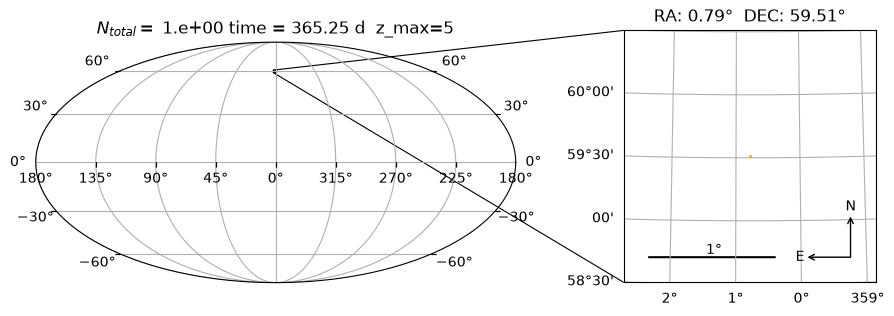

In [ ]:
plot_population(population, ra_dec_zoom=[float(population['ra'][0]), float(population['dec'][0])])

In [ ]:
population

{'z': array([1.78685105]),
 'z_max': 5,
 'ra': array([0.78556679]),
 'dec': array([59.51122829]),
 'time_window': <Quantity 1. yr>}

In [ ]:
R0

NameError: name 'R0' is not defined

In [ ]:
def tripp1998( x1, c,
                   mabs=-19.3, sigmaint=0.10,
                   alpha=-0.14, beta=3.15, rng=None):
        """Get the 2-parameter absolute (natural) SNe Ia magnitude.

        Parameters
        ----------
        x1 : array
            The lightcurve stretch. `x1` and `c` must have the same size.

        c : array
            The lightcurve color. `x1` and `c` must have the same size.

        mabs : float, optional
            The average absolute magnitude at `c=0` and `x1=0`. The default is
            -19.3.

        sigmaint : float, optional
            The scale of the normal grey scatter (on `mabs`). The default is
            0.10.

        alpha : float, optional
            The stretch linear law coefficient. The default is -0.14.

        beta : float, optional
            The color linear law coeeficient. The default is 3.15.

        rng: None, int, Generator
            Random number generator seed. 
            (docstring extracted from `np.random.default_rng()`, see this for complete documentation).
            If None, then fresh, unpredictable entropy will be pulled from the OS. 
            If an ``int``, then the seed will start from this.
            If passed a `Generator`, it will be returned unaltered.

        Returns
        -------
        array
           The absolute magnitude, with the same format as `x1` and `c`.
        """
        rng = np.random.default_rng(rng)
        mabs = rng.normal(loc=mabs, scale=sigmaint, size=len(x1))
        mabs_notstandard = mabs + (x1*alpha + c*beta)
        return mabs_notstandard

def nicolas2021( xx="-4:4:0.005", 
                     mu1=0.33, sigma1=0.64, 
                     mu2=-1.50, sigma2=0.58, a=0.45,
                     fprompt=0.5):
        """Get the pdf of the Nicolas (2021) model.

        Parameters
        ----------
        xx : str or array, optional
            Definition range for the parameters. Draws will be done from this
            array given the pdf that will be estimated for it. If a string is
            given, it is evaluated as `np.r_[xx]`. The default is
            "-4:4:0.005".

        mu1 : float, optional
            The mean of the first gaussian. The default is 0.33.

        sigma1 : float, optional
            The standard deviation of the first gaussian. The default is 0.64.

        mu2 : float, optional
            The mean of the second gaussian. The default is -1.50.

        sigma2 : float, optional
            The standard deviation of the second gaussian. The default is 0.58.

        a : float, optional
            The relative influence of both modes (1 or 2) in the delayed
            environment. `a>0.5` means more mode 1. The default is 0.45.

        fprompt : float, optional
            The fraction of prompt SNe Ia. This is ignored if `redshift` is
            given. The default is 0.5.

        Returns
        -------
        tuple
            A tuple containing the x-axis and the pdf.
        """
        from scipy.stats import norm
        if type(xx) is str: # assumed r_ input
            xx = eval(f"np.r_[{xx}]")
            
        mode1 = norm.pdf(xx, loc=mu1, scale=sigma1)
        mode2 = norm.pdf(xx, loc=mu2, scale=sigma2)
        if type(fprompt) is not float: 
            fprompt = np.asarray(fprompt)[:,None]
            
        pdf = fprompt*mode1 + (1-fprompt)*(a*mode1 + (1-a)*mode2)
        return xx, pdf

In [3]:
from skysurvey.tools.utils import random_radec
# from skysurvey.effects.milkyway import get_mwebv
import astropy.units as u
import astropy.cosmology as acosmo
from params import p_cosmology
from transient_rates import R_SFR, R_TDE, R_sGRB_gaus

rate_funtions = {
        'SN Ia': R_SFR,
        'SN Ibc': R_SFR,
        'SN IIn': R_SFR,
        'TDE': R_TDE,
        'KN': R_sGRB_gaus
    }
transient_type = 'SN Ia'
sample_size = 1
R_z = rate_funtions[transient_type] 
R0 = p_cosmology['R0'][transient_type]
z_max = 5.0
z_grid = np.linspace(p_cosmology['z_min'], z_max, 1000)
rates_k = R_z(z_grid, R0.to(u.Mpc ** -3 * u.yr ** -1))

p_k = rates_k / np.sum(rates_k)
redshift_sample = np.random.choice(z_grid, p=p_k, size=sample_size)

z_choice = 1.0
time = 1*u.d

def fixed_z(size, z=z_choice):
    return np.full(size, z)

flat_model = {"c": {"func": np.random.uniform, "kwargs": {"low":-1, "high":+3}},
             'radec': {'func': random_radec,
            'kwargs': {},
            'as': ['ra', 'dec']},
             "z": {"func": fixed_z, "kwargs": {"size": 1}}}

# "redshift": {"func": np.random.choice, "kwargs": {"a": z_grid, "p": p_k, "size": sample_size}

# flat_model = {'redshift': {'as': 'z',
#               'func': 'draw_redshift',
#               'kwargs': {"rate": R0, "zmin": 0.01, "zmax": 0.01}},
#               "x1": {"func": np.random.uniform, "kwargs": {"low":-3, "high":+3}},
#               'radec': {'func': random_radec,
#            'kwargs': {},
#            'as': ['ra', 'dec']},
#              }

# custom_model = {"redshift": {"func": fixed_z, "kwargs": {"size": 1}},
#  'x1': {'func': nicolas2021},
#  'c': {'func': np.random.uniform,
#        'kwargs': {'low': -1, 'high': 3}},
#  't0': {'func': np.random.uniform,
#         'kwargs': {'low': 56000, 'high': 56200}},
#  'magabs': {'func': tripp1998,
#             'kwargs': {'x1': '@x1',
#                        'c': '@c',
#                        'mabs': -19.3,
#                        'sigmaint': 0.1,
#                        'alpha': -0.15,
#                        'beta': 3.8}},
#  'magobs': {'func': 'magabs_to_magobs',
#             'kwargs': {'z': '@z', 'magabs': '@magabs'}},
# #  'x0': {'func': 'magobs_to_amplitude',
# #         'kwargs': {'magobs': '@magobs', 'param_name': 'x0'}},
#  'radec': {'func': random_radec,
#            'kwargs': {},
#            'as': ['ra', 'dec']}}
custom_model = {
    "redshift": {
        "func": fixed_z,
        "kwargs": {"z": z_choice},
        "as": "z",
    }
}


snia = skysurvey.SNeIa()
snia.update_model(**custom_model)

print(snia.model)

new_snia = snia.from_draw(1, model = custom_model)
print(new_snia.data["z"][0])
new_snia.model

{'redshift': {'func': <function fixed_z at 0x7b59da6b5dd0>,
              'kwargs': {'z': 1.0},
              'as': 'z'},
 'x1': {'func': <function SNeIaStretch.nicolas2021 at 0x7b59dd649380>,
        'kwargs': {}},
 'c': {'func': <function SNeIaColor.intrinsic_and_dust at 0x7b59dd6492d0>,
       'kwargs': {}},
 't0': {'func': <bound method Generator.uniform of Generator(PCG64) at 0x7B59DD8C4040>,
        'kwargs': {'low': 56000, 'high': 56200}},
 'magabs': {'func': <function SNeIaMagnitude.tripp1998 at 0x7b59dd649430>,
            'kwargs': {'x1': '@x1', 'c': '@c', 'mabs': -19.3, 'sigmaint': 0.1}},
 'magobs': {'func': 'magabs_to_magobs',
            'kwargs': {'z': '@z', 'magabs': '@magabs'}},
 'radec': {'func': <function random_radec at 0x7b59dd5f8250>,
           'kwargs': {},
           'as': ['ra', 'dec']}}
1.0


{'redshift': {'func': <function fixed_z at 0x7b59da6b5dd0>,
              'kwargs': {'z': 1.0},
              'as': 'z'},
 'x1': {'func': <function SNeIaStretch.nicolas2021 at 0x7b59dd649380>,
        'kwargs': {}},
 'c': {'func': <function SNeIaColor.intrinsic_and_dust at 0x7b59dd6492d0>,
       'kwargs': {}},
 't0': {'func': <bound method Generator.uniform of Generator(PCG64) at 0x7B59DD8C52A0>,
        'kwargs': {'low': 56000, 'high': 56200}},
 'magabs': {'func': <function SNeIaMagnitude.tripp1998 at 0x7b59dd649430>,
            'kwargs': {'x1': '@x1', 'c': '@c', 'mabs': -19.3, 'sigmaint': 0.1}},
 'magobs': {'func': 'magabs_to_magobs',
            'kwargs': {'z': '@z', 'magabs': '@magabs'}},
 'radec': {'func': <function random_radec at 0x7b59dd5f8250>,
           'kwargs': {},
           'as': ['ra', 'dec']}}

In [122]:
new_template = new_snia.get_template(0)
new_template.sncosmo_model.parameters

array([ 1.00000000e+00,  5.61286172e+04,  1.00000000e+00,  9.30000007e-01,
       -4.99999989e-03])

In [58]:
print(inspect.getsource(skysurvey.SNeIa.from_draw))

    @classmethod
    def from_draw(cls, size=None, model=None, template=None,
                      zmax=None, tstart=None, tstop=None,
                      zmin=0, nyears=None,
                      skyarea=None, rate=None,
                      effect=None,
                      cosmology=None,
                      verbose=False,
                      set_amplitude=False,
                      **kwargs):
        """Load the instance from a random draw of targets given the model.

        kwargs may hold specific transient options like:
        - magabs for TSTransient(){self._additional_input}
        (see class.__init__).
        
        Parameters
        ----------
        size : int, optional
            Number of target you want to sample. If None, 1 is assumed.
            Ignored if `nyears` is given. By default None.
        model : dict, optional
            Defines how template parameters are drawn and how they are
            connected. The model will update the default

In [54]:
new_snia.data

,z,x1,c,t0,ra,dec,magabs,magobs,template
0,0.5,-1.385,-0.036,56128.617188,165.76889,-58.101131,-19.240446,19.265411,salt2


In [55]:
print(new_snia.model)
new_snia.data["z"] = 0.5
print(new_snia.model)

{'redshift': {'func': 'draw_redshift',
              'kwargs': {'zmax': 0.2, 'rate': 23500.0, 'zmin': 0},
              'as': 'z'},
 'x1': {'func': <function SNeIaStretch.nicolas2021 at 0x70a541c75590>,
        'kwargs': {}},
 'c': {'func': <function SNeIaColor.intrinsic_and_dust at 0x70a541c754e0>,
       'kwargs': {}},
 't0': {'func': <bound method Generator.uniform of Generator(PCG64) at 0x70A53E8F4660>,
        'kwargs': {'low': 56000, 'high': 56200}},
 'magabs': {'func': <function SNeIaMagnitude.tripp1998 at 0x70a541c75640>,
            'kwargs': {'x1': '@x1', 'c': '@c', 'mabs': -19.3, 'sigmaint': 0.1}},
 'magobs': {'func': 'magabs_to_magobs',
            'kwargs': {'z': '@z', 'magabs': '@magabs'}},
 'radec': {'func': <function random_radec at 0x70a541c28460>,
           'kwargs': {},
           'as': ['ra', 'dec']}}
{'redshift': {'func': 'draw_redshift',
              'kwargs': {'zmax': 0.2, 'rate': 23500.0, 'zmin': 0},
              'as': 'z'},
 'x1': {'func': <function SNeIaStr

In [56]:
print(skysurvey.SNeIa.update_model.__doc__)

Change the given entries of the model.

Parameters
----------
rate_update : bool, optional
    [description], by default True
**kwargs
    Will update any model entry (or create a new one at the end).

Examples
--------
Changing the `b` entry function and make it depends on `a`
>>> rng = np.random.default_rng()
>>> self.update_model(b={"func":rng.normal, "kwargs":{"loc":"@a", "scale":1}})



In [11]:
import inspect
print(inspect.signature(skysurvey.SNeIa.from_draw))
print(getattr(new_snia, "tstart", None))
print(getattr(new_snia, "tstop", None))
print(new_snia.__dict__.keys())
print(inspect.signature(skysurvey.SNeIa.show_lightcurve))

(size=None, model=None, template=None, zmax=None, tstart=None, tstop=None, zmin=0, nyears=None, skyarea=None, rate=None, effect=None, cosmology=None, verbose=False, set_amplitude=False, **kwargs)
None
None
dict_keys(['_model', '_rate', '_cosmology', '_template', '_data'])
(self, band, index, params=None, ax=None, fig=None, colors=None, phase_range=None, npoints=500, zp=25, zpsys='ab', format_time=True, t0_format='mjd', in_mag=False, invert_mag=True, **kwargs)


     z     x1      c            t0         ra        dec     magabs  \
0  0.5  0.665 -0.121  56128.617188  12.117336 -33.999893 -19.690283   

      magobs template  
0  22.636353    salt2  
{'redshift': {'func': <function fixed_z at 0x70a53f11cbf0>,
              'kwargs': {'z': 0.5},
              'as': 'z'},
 'x1': {'func': <function SNeIaStretch.nicolas2021 at 0x70a541c75590>,
        'kwargs': {}},
 'c': {'func': <function SNeIaColor.intrinsic_and_dust at 0x70a541c754e0>,
       'kwargs': {}},
 't0': {'func': <bound method Generator.uniform of Generator(PCG64) at 0x70A53F4F5540>,
        'kwargs': {'low': 56000, 'high': 56200}},
 'magabs': {'func': <function SNeIaMagnitude.tripp1998 at 0x70a541c75640>,
            'kwargs': {'x1': '@x1', 'c': '@c', 'mabs': -19.3, 'sigmaint': 0.1}},
 'magobs': {'func': 'magabs_to_magobs',
            'kwargs': {'z': '@z', 'magabs': '@magabs'}},
 'radec': {'func': <function random_radec at 0x70a541c28460>,
           'kwargs': {},
           'as': [

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: divide by zero encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)
/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)


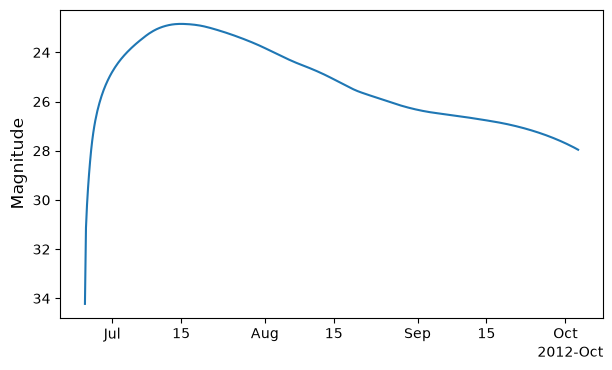

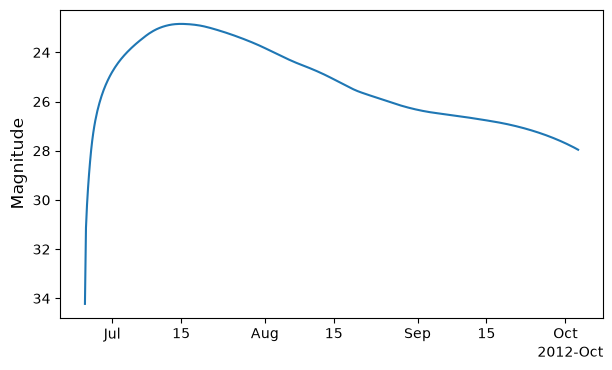

In [63]:
new_snia.show_lightcurve("lsstg", index = 0, in_mag = True)
print(new_snia.data)
print(new_snia.model)
print(new_snia.model.model)
# new_snia.data["z"] = 0.255
print(new_snia.model)
print(new_snia.model.model)
ax = new_snia.show_lightcurve("lsstg", index = 0, in_mag = True)
# print(new_snia.data)

In [131]:
new_snia.get_source().get_sn_cosmomodel

AttributeError: 'SNeIa' object has no attribute 'get_source'

In [18]:
fig = new_snia.show_lightcurve(["lsstu", "lsstg"], index = 0, times = times, in_mag = True)
# print(new_snia.data)
ax = fig.axes[0]
ax.legend(ax.lines, ["lsstu", "lsstg"])
for line in ax.lines:
    print(line.get_label())

ValueError: bandpass 'lsstu' [3105, .., 4086] outside spectral range [4000, .., 18400]

In [9]:
limit_mag_dict = {
                "lsstu": {"mag": 23.8, "color": "tab:purple"},
              "lsstg": {"mag": 24.5, "color": "tab:green"},
              "lsstr": {"mag": 24.0, "color": "tab:orange"},
              "lssti": {"mag": 23.4, "color": "tab:red"},
              "lsstz": {"mag": 22.7, "color": "tab:brown"},
              "lssty": {"mag": 22.0, "color": '0.5'},
              }

lsst_colors = ["tab:purple", "tab:green", "tab:orange", "tab:red", "tab:brown", "0.5"]

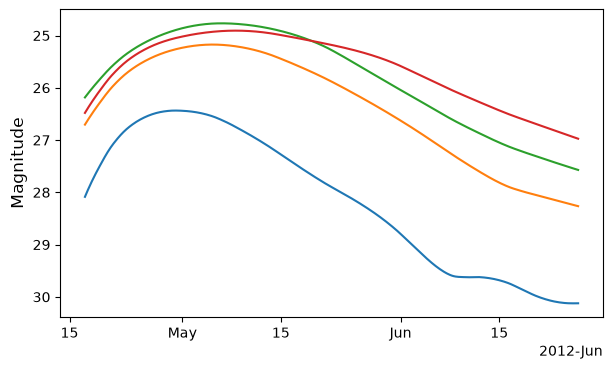

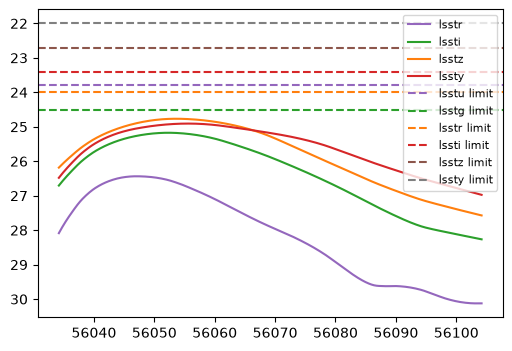

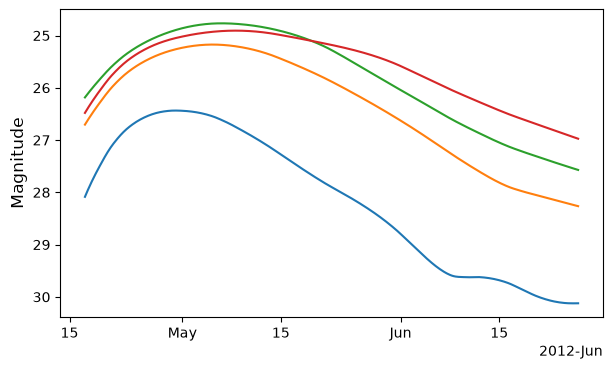

In [15]:
t0 = new_snia.data["t0"][0] #series --> value
# https://skysurvey.readthedocs.io/en/latest/_modules/skysurvey/template.html#Template.show_lightcurve

phase_start = new_snia.template.get().mintime()
phase_stop = min(new_snia.template.get().maxtime(), 200.0)
times = np.linspace(phase_start, phase_stop, 500) + t0
bands = ["lsstr", "lssti", "lsstz", "lssty"]
lc = new_snia.get_lightcurve(bands, phase_range = (phase_start, phase_stop), times=times,index=0,zp=25,in_mag=True)
fig, ax = plt.subplots(figsize=(6, 4))

for i in range(len(bands)):
    ax.plot(times, lc[i], label=bands[i], color=lsst_colors[i])

for band, v in limit_mag_dict.items():
    ax.axhline(v["mag"], color=v["color"], linestyle="--", label=f"{band} limit")

ax.invert_yaxis()
ax.legend(fontsize=8)

fig
# plt.show()
new_snia.show_lightcurve(bands, phase_range = (phase_start, phase_stop), index = 0, zp = 25, in_mag = True)

In [17]:
np.column_stack([times] + list(lc))[0]

array([5.60341914e+04, 2.80860663e+01, 2.67047556e+01, 2.61842816e+01,
       2.64803175e+01])

In [80]:
population_dict = new_snia.data.to_dict()
population_dict
new_snia.get_target_template(index = 0)


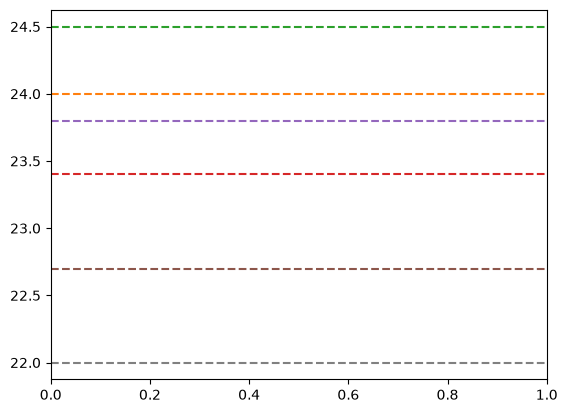

In [241]:
# limiting magnitudes at start of LSST. See if you need to use a dict instead.
limit_mag_dict = {
                "lsstu": {"mag": 23.8, "color": "tab:purple"},
              "lsstg": {"mag": 24.5, "color": "tab:green"},
              "lsstr": {"mag": 24.0, "color": "tab:orange"},
              "lssti": {"mag": 23.4, "color": "tab:red"},
              "lsstz": {"mag": 22.7, "color": "tab:brown"},
              "lssty": {"mag": 22.0, "color": '0.5'},
              }

for band, v in limit_mag_dict.items():
    plt.gca().axhline(v["mag"], color=v["color"], linestyle="--", label=f"{band} limit")

# limit_mag_dict["u"]["color"]

In [ ]:
source = new_snia.template.get().source

from skysurvey.template import get_sn_cosmomodel
get_sn_cosmomodel(source)
# print(new_snia.model.model)

import sncosmo
bp = sncosmo.get_bandpass("lsstg")
print(bp.minwave())
new_snia.model.model

ImportError: cannot import name 'get_sn_cosmomodel' from 'skysurvey' (/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/skysurvey/__init__.py)

In [4]:
import pandas as pd


bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]

def make_visibility_row(lc, bands, limit_mag_dict):
    row = {}
    for i, band in enumerate(bands):
        mag_vals = np.asarray(lc[i])   # works for tuple/list/ndarray
        visible = int(np.any(mag_vals < limit_mag_dict[band]["mag"]))
        row[band] = visible
    return row

target_ids = [0]   # add more event IDs later if needed
rows = []

for target_id in target_ids:
    lc = new_snia.get_lightcurve(
        band = bands,
        times=times,
        index=target_id,
        zp=25,
        in_mag=True,
    )
    rows.append(make_visibility_row(lc, bands, limit_mag_dict))

sn_visibility = pd.DataFrame(rows, index=target_ids)
sn_visibility.index.name = "target_id"
print(sn_visibility)

sn_visibility_dict = sn_visibility.to_dict()
sn_visibility_dict

NameError: name 'times' is not defined

In [ ]:
help(new_snia.show_lightcurve)

Help on method show_lightcurve in module skysurvey.target.core:

show_lightcurve(
    band,
    index,
    params=None,
    ax=None,
    fig=None,
    colors=None,
    phase_range=None,
    npoints=500,
    zp=25,
    zpsys='ab',
    format_time=True,
    t0_format='mjd',
    in_mag=False,
    invert_mag=True,
    **kwargs
) method of skysurvey.target.snia.SNeIa instance
    Show the lightcurve.

    Parameters
    ----------
    band : str
        The band to show.
    index : int
        The index of the target.
    params : dict, optional
        Parameters to pass to `get_target_template`. By default None.
    ax : matplotlib.axes.Axes, optional
        The axes to show the lightcurve on. By default None.
    fig : matplotlib.figure.Figure, optional
        The figure to show the lightcurve on. By default None.
    colors : list, optional
        The colors to use for the lightcurve. By default None.
    phase_range : list, optional
        The phase range to show. By default None.

,z,x1,c,t0,ra,dec,magabs,magobs,template
0,1.0,0.565,0.23,56011.664062,187.058716,-14.551133,-18.784029,19.006468,salt2


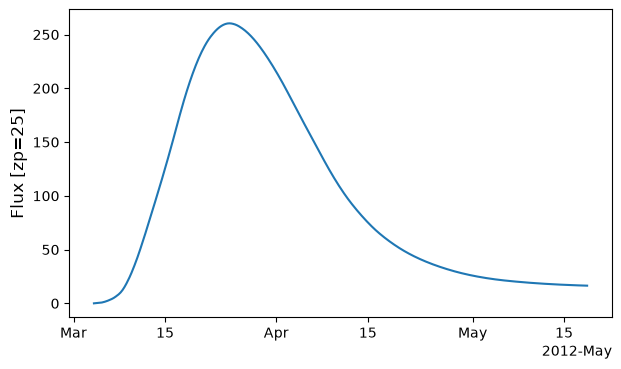

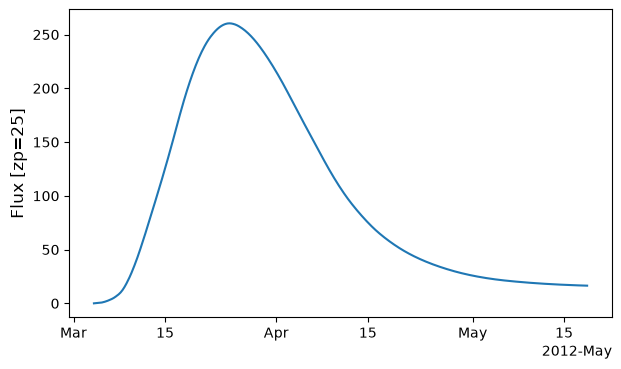

In [ ]:
new_snia.show_lightcurve("lsstg", index = 0)

In [ ]:

new_snia.data

,z,x1,c,t0,ra,dec,magabs,magobs,template
0,0.255,-0.335,-0.131,56011.664062,152.29985,-11.862591,-19.671741,19.953001,salt2


In [ ]:
new_snia.show_lightcurve("lsstg", index = 0)

new_snia.data["z"].value = 1.0

new_snia.show_lightcurve("lsstg", index = 0)


ValueError: bandpass 'lsstg' [3866, .., 5670] outside spectral range [4000, .., 18400]

In [ ]:
new_snia

In [ ]:
custom_model

{'redshift': {'func': <function __main__.fixed_z(size, z=1.0)>,
  'kwargs': {'size': 1}}}

In [ ]:
flat_model

{'c': {'func': <bound method RandomState.uniform of RandomState(MT19937) at 0x7E24C7127C40>,
  'kwargs': {'low': -1, 'high': 3}},
 'radec': {'func': <function skysurvey.tools.utils.random_radec(size=None, skyarea=None, ra_range=[0, 360], dec_range=[-90, 90], rng=None)>,
  'kwargs': {},
  'as': ['ra', 'dec']},
 'z': {'func': <function __main__.fixed_z(size, z=1.0)>,
  'kwargs': {'size': 1}}}

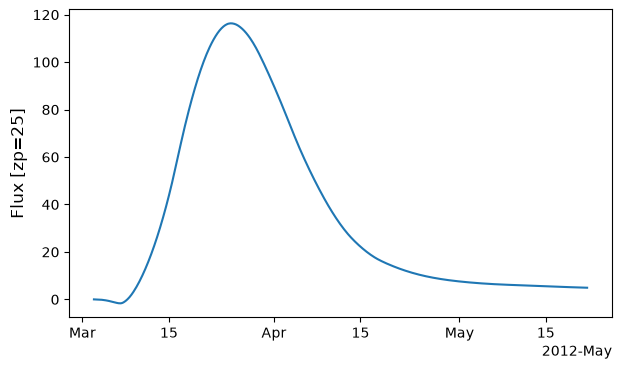

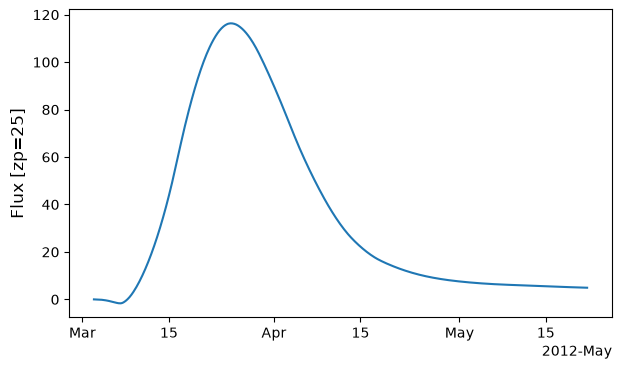

In [ ]:
new_snia.show_lightcurve(("lsstg"), index = 0, colors = None)

In [ ]:
skusurvey.SNeIa().model()

NameError: name 'skusurvey' is not defined

In [ ]:
print(data["z"])

_ = snia.show_lightcurve(
    ("lsstg", "lsstr"),
    index=0,
    colors=None,
    phase_range=(-50, 100),
)

0    1.0
Name: z, dtype: float64


AttributeError: 'NoneType' object has no attribute 'columns'

In [ ]:
_ = snia.show_lightcurve(("lsstu", "lsstg", "lsstr", "lssti", "lsstz"), index = 0, colors = None)

AttributeError: 'NoneType' object has no attribute 'columns'

In [ ]:
snia.model.model

{'redshift': {'kwargs': {'zmax': 5.0, 'rate': 23500.0}, 'as': 'z'},
 'x1': {'func': <bound method RandomState.uniform of RandomState(MT19937) at 0x7E2475774D40>,
  'kwargs': {'low': -3, 'high': 3}},
 'c': {'func': <function skysurvey.target.snia.SNeIaColor.intrinsic_and_dust(xx='-0.3:1:0.001', cint=-0.075, sigmaint=0.05, tau=0.14)>,
  'kwargs': {}},
 't0': {'func': <bound method Generator.uniform of Generator(PCG64) at 0x7E248691F680>,
  'kwargs': {'low': 56000, 'high': 56200}},
 'magabs': {'func': <function skysurvey.target.snia.SNeIaMagnitude.tripp1998(x1, c, mabs=-19.3, sigmaint=0.1, alpha=-0.14, beta=3.15, rng=None)>,
  'kwargs': {'x1': '@x1', 'c': '@c', 'mabs': -19.3, 'sigmaint': 0.1}},
 'magobs': {'func': 'magabs_to_magobs',
  'kwargs': {'z': '@z', 'magabs': '@magabs'}},
 'radec': {'func': <function skysurvey.tools.utils.random_radec(size=None, skyarea=None, ra_range=[0, 360], dec_range=[-90, 90], rng=None)>,
  'kwargs': {},
  'as': ['ra', 'dec']}}

In [ ]:
# make lightcurve from this
import skysurvey
# something .show_lightcurve(). # what is the data"

In [ ]:
population
# use population["z"] = ... to fix the value!

{'z': array([1.15122813]),
 'z_max': 5,
 'ra': array([175.75836691]),
 'dec': array([84.57106864]),
 'time_window': <Quantity 1. yr>}

## Testing out lightcurve.py

In [86]:
from lightcurve import generate_snia_lightcurve

In [87]:
generate_snia_lightcurve(bands = bands, redshift = 1)

KeyError: 'z_max'